# EDA — Fall Guardian v3 (Week A data foundation)

This notebook validates the Week A data-foundation work end-to-end against the
real WEDA-FALL recordings. It covers three things:

1. **Visual verification** — pick a handful of fall recordings, plot the raw
   acceleration magnitude, and overlay the derived `t_impact` line and the
   PRE_IMPACT / IMPACT / POST_IMPACT phase windows. If the impact peak isn't
   visibly the largest spike inside the labelled fall window, the derivation
   has a bug.
2. **Alignment check** — for every fall recording in the dataset, compute the
   lag between the derived `t_impact` and the dataset's manual `start_time`
   label. Plot the distribution. Expected behaviour: lag is positive, mostly
   0.5–1.5 s, and the peak magnitudes are well above the 20 m/s² (~2g) sanity
   threshold.
3. **Profiles** — average `|a|(t)` across fall types and ADL types. Falls
   should show a sharp spike around `t_impact`; ADLs should be a roughly flat
   band around 1g. If they look identical, the engineered features won't be
   able to separate them either.

## How to run

```bash
cd ml
uv run jupyter lab notebooks/01_eda.ipynb        # interactive
# or, non-interactively:
uv run jupyter nbconvert --to notebook --execute --inplace notebooks/01_eda.ipynb
```

Outputs are committed to the repo so visitors can read this on GitHub without
running anything locally.

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from fall_guardian_ml.datasets.weda_fall import (
    discover_recordings,
    load_fall_timestamps,
    load_recording,
    ADL_CODES,
    FALL_CODES,
    TARGET_HZ,
)
from fall_guardian_ml.datasets.pre_impact_labels import (
    Phase,
    assign_phase_labels,
    find_impact,
)
from fall_guardian_ml.features.extraction import magnitude

DATA_ROOT = Path("../data/raw/WEDA-FALL-main").resolve()
print(f"Data root:    {DATA_ROOT}")
print(f"Exists:       {DATA_ROOT.exists()}")

fall_ts = load_fall_timestamps(DATA_ROOT)
fall_records = discover_recordings(DATA_ROOT, movements=FALL_CODES)
adl_records = discover_recordings(DATA_ROOT, movements=ADL_CODES)

print(f"\nFall recordings: {len(fall_records)}")
print(f"ADL  recordings: {len(adl_records)}")
print(f"Fall labels in CSV: {len(fall_ts)}")
print(f"\nFirst few fall labels:")
print(fall_ts.head().to_string(index=False))

Data root:    C:\Users\devgu\Downloads\Project\Personal\Repos\fall-detect-system\ml\data\raw\WEDA-FALL-main
Exists:       True

Fall recordings: 350
ADL  recordings: 619
Fall labels in CSV: 350

First few fall labels:
   filename  start_time  end_time
F01/U01_R01         4.7       7.7
F01/U01_R02         4.7       7.7
F01/U01_R03         5.0       8.0
F02/U01_R01         5.1       8.1
F02/U01_R02         5.7       8.7


## 1. Visual verification — derived `t_impact` and phase windows

Pick 6 random fall recordings (different fall types and subjects), plot the
acceleration magnitude `|a|` over time, and overlay:

- The dataset's manually-labelled fall window (light gray shading).
- Our derived `t_impact` (black dashed line).
- The PRE_IMPACT (yellow) / IMPACT (red) / POST_IMPACT (orange) phase regions.

The black dashed line should sit on the visibly tallest spike inside the
gray window. The yellow band should appear immediately before the spike (the
500 ms pre-impact window we want the edge model to fire in).

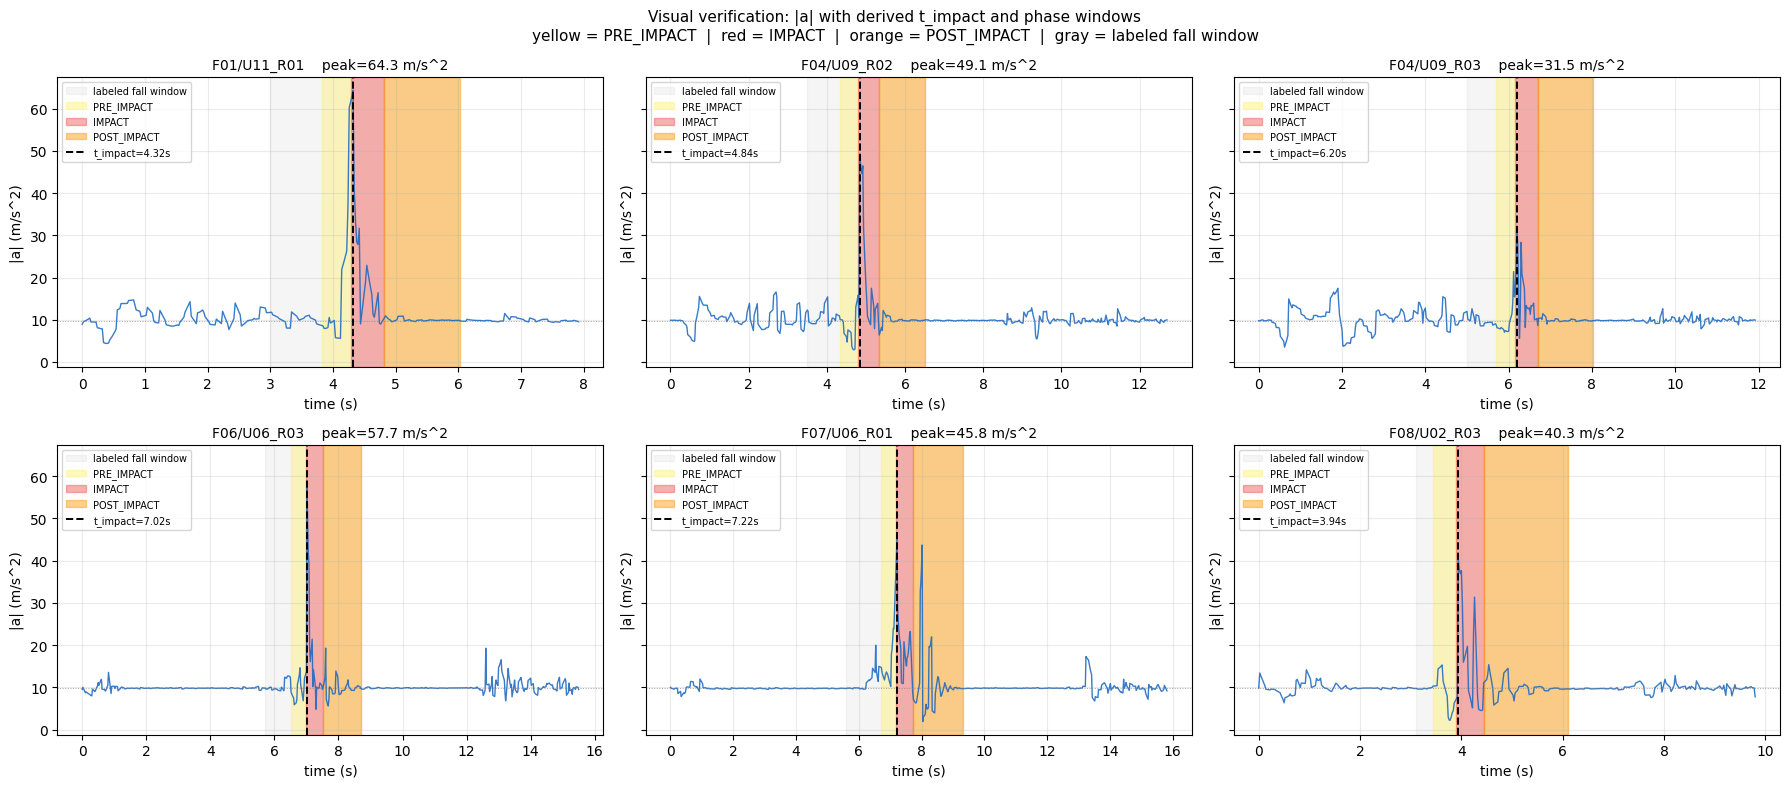

In [2]:
def _phase_runs(time_s, labels, phase_value):
    '''Yield (start_t, end_t) contiguous ranges where labels == phase_value.'''
    mask = (labels == phase_value)
    if not mask.any():
        return
    diff = np.diff(mask.astype(np.int8))
    starts = (np.where(diff == 1)[0] + 1).tolist()
    ends = (np.where(diff == -1)[0] + 1).tolist()
    if mask[0]:
        starts.insert(0, 0)
    if mask[-1]:
        ends.append(len(mask))
    for s, e in zip(starts, ends):
        yield float(time_s[s]), float(time_s[min(e, len(time_s) - 1)])


PHASE_COLORS = {
    Phase.PRE_IMPACT.value:  ("#fff176", "PRE_IMPACT"),
    Phase.IMPACT.value:      ("#ef5350", "IMPACT"),
    Phase.POST_IMPACT.value: ("#ff9800", "POST_IMPACT"),
}

rng = np.random.default_rng(seed=42)
chosen_idx = rng.choice(len(fall_records), size=6, replace=False)
chosen = [fall_records[int(i)] for i in sorted(chosen_idx)]

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey=True)
for ax, rec_id in zip(axes.flat, chosen):
    rec = load_recording(DATA_ROOT, rec_id, fall_timestamps=fall_ts,
                         include_orientation=False)
    mag = magnitude(rec.accel)
    ann = find_impact(rec.time, rec.accel, rec.fall_window)

    ax.plot(rec.time, mag, color="#1565c0", lw=1.0, alpha=0.85)
    ax.axhline(9.81, color="gray", ls=":", lw=0.7, alpha=0.7)

    fw_s, fw_e = rec.fall_window
    ax.axvspan(fw_s, fw_e, color="gray", alpha=0.08,
               label="labeled fall window")

    if ann.valid:
        labels = assign_phase_labels(rec.time, ann.t_impact_s, rec.fall_window)
        seen = set()
        for phase_val, (color, name) in PHASE_COLORS.items():
            for t0, t1 in _phase_runs(rec.time, labels, phase_val):
                lbl = name if name not in seen else None
                seen.add(name)
                ax.axvspan(t0, t1, color=color, alpha=0.45, label=lbl)
        ax.axvline(ann.t_impact_s, color="black", ls="--", lw=1.4,
                   label=f"t_impact={ann.t_impact_s:.2f}s")

    ax.set_title(
        f"{rec_id.label_key}    peak={ann.peak_magnitude_ms2:.1f} m/s^2",
        fontsize=10,
    )
    ax.set_xlabel("time (s)")
    ax.set_ylabel("|a| (m/s^2)")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7, loc="upper left")

fig.suptitle(
    "Visual verification: |a| with derived t_impact and phase windows\n"
    "yellow = PRE_IMPACT  |  red = IMPACT  |  orange = POST_IMPACT  |  gray = labeled fall window",
    fontsize=11,
)
fig.tight_layout()
plt.show()

## 2. Alignment check — lag between derived `t_impact` and labelled `start_time`

For every fall recording in WEDA-FALL, compute the derived `t_impact` and
compare it to the dataset's manual `start_time` label.

The expected story:

- **Lag is strictly positive** — the impact peak follows the fall onset.
- **Lag mostly falls in 0.5–1.5 s** — typical fall sequence duration.
- **Peak magnitudes are well above 20 m/s²** — the sanity threshold is not
  pruning real falls.

Any deviation from the above is a signal to investigate (the dataset author
acknowledges the manual labels "can have mistakes").

In [3]:
records_for_lag = []
errors = []

for rec_id in fall_records:
    try:
        rec = load_recording(
            DATA_ROOT, rec_id,
            fall_timestamps=fall_ts,
            include_orientation=False,
        )
        if rec.fall_window is None:
            continue
        ann = find_impact(rec.time, rec.accel, rec.fall_window)
        records_for_lag.append({
            "label_key": rec_id.label_key,
            "movement": rec_id.movement,
            "user_id": rec_id.user_id,
            "trial": rec_id.trial,
            "t_impact_s": ann.t_impact_s,
            "peak_magnitude_ms2": ann.peak_magnitude_ms2,
            "lag_s": ann.lag_from_label_start_s,
            "valid": ann.valid,
            "reason": ann.reason,
        })
    except Exception as exc:
        errors.append((rec_id.label_key, str(exc)))

lag_df = pd.DataFrame(records_for_lag)
valid_df = lag_df[lag_df["valid"]].copy()
invalid_df = lag_df[~lag_df["valid"]]

print(f"Processed {len(lag_df)} fall recordings:")
print(f"  valid   (peak >= 20 m/s^2):  {len(valid_df)}")
print(f"  invalid (peak  < 20 m/s^2):  {len(invalid_df)}")
print(f"  load errors:                  {len(errors)}")

if len(invalid_df):
    print("\nInvalid (first 10):")
    print(invalid_df[["label_key", "peak_magnitude_ms2", "reason"]]
          .head(10).to_string(index=False))

print(f"\nLag statistics (t_impact - start_time, in seconds):")
print(valid_df["lag_s"].describe()[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
].to_string())

print(f"\nPeak magnitude statistics (|a| at t_impact, m/s^2):")
print(valid_df["peak_magnitude_ms2"].describe()[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
].to_string())

Processed 350 fall recordings:
  valid   (peak >= 20 m/s^2):  349
  invalid (peak  < 20 m/s^2):  1
  load errors:                  0

Invalid (first 10):
  label_key  peak_magnitude_ms2                                   reason
F05/U11_R02            17.93865 peak |a|=17.94 m/s² below threshold 20.0

Lag statistics (t_impact - start_time, in seconds):
count    349.000000
mean       1.234670
std        0.309271
min        0.040000
25%        1.040000
50%        1.200000
75%        1.340000
max        3.260000

Peak magnitude statistics (|a| at t_impact, m/s^2):
count    349.000000
mean      47.885993
std        9.791663
min       20.378911
25%       40.600246
50%       48.730818
75%       55.632891
max       67.781118


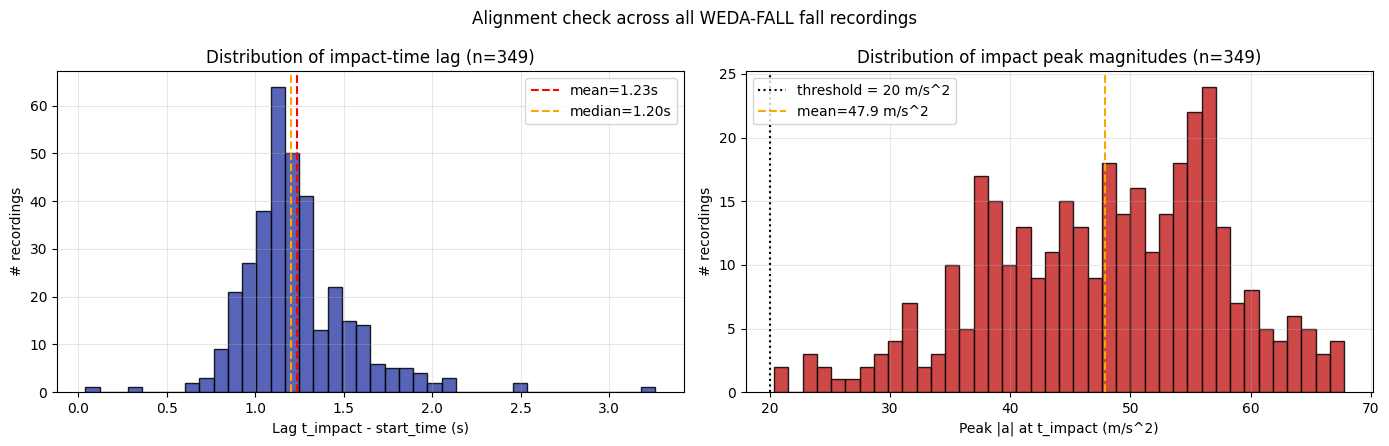

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# (a) Lag distribution -------------------------------------------------------
axes[0].hist(valid_df["lag_s"], bins=40, color="#3949ab",
             alpha=0.85, edgecolor="black")
axes[0].axvline(valid_df["lag_s"].mean(), color="red", ls="--",
                label=f"mean={valid_df['lag_s'].mean():.2f}s")
axes[0].axvline(valid_df["lag_s"].median(), color="orange", ls="--",
                label=f"median={valid_df['lag_s'].median():.2f}s")
axes[0].set_xlabel("Lag t_impact - start_time (s)")
axes[0].set_ylabel("# recordings")
axes[0].set_title(f"Distribution of impact-time lag (n={len(valid_df)})")
axes[0].legend()
axes[0].grid(alpha=0.3)

# (b) Peak magnitudes --------------------------------------------------------
axes[1].hist(valid_df["peak_magnitude_ms2"], bins=40, color="#c62828",
             alpha=0.85, edgecolor="black")
axes[1].axvline(20.0, color="black", ls=":", label="threshold = 20 m/s^2")
axes[1].axvline(valid_df["peak_magnitude_ms2"].mean(), color="orange",
                ls="--",
                label=f"mean={valid_df['peak_magnitude_ms2'].mean():.1f} m/s^2")
axes[1].set_xlabel("Peak |a| at t_impact (m/s^2)")
axes[1].set_ylabel("# recordings")
axes[1].set_title(f"Distribution of impact peak magnitudes (n={len(valid_df)})")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle("Alignment check across all WEDA-FALL fall recordings",
             fontsize=12)
fig.tight_layout()
plt.show()

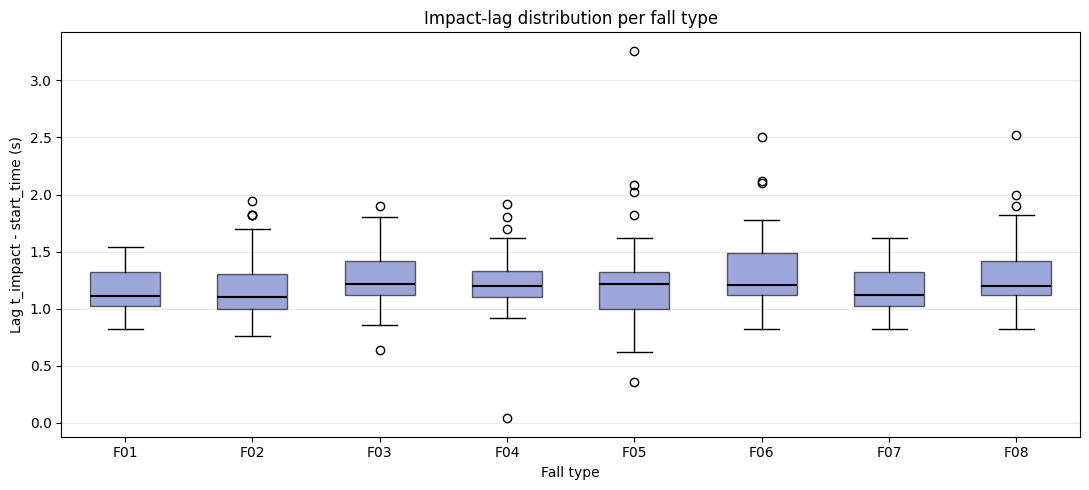

In [5]:
# Per-fall-type lag breakdown — a fall code that systematically lags by a
# different amount could indicate a labelling-style difference for that
# fall type. We expect F05/F06/F07/F08 (sit-down falls) to have shorter
# lags than F01-F04 (walking-then-falling) because the pre-fall phase is
# shorter.

fig, ax = plt.subplots(figsize=(11, 5))
fall_types = sorted(valid_df["movement"].unique())
data = [valid_df[valid_df["movement"] == ft]["lag_s"].values
        for ft in fall_types]
bp = ax.boxplot(data, positions=np.arange(len(fall_types)),
                widths=0.55, patch_artist=True)
for box in bp["boxes"]:
    box.set(facecolor="#5c6bc0", alpha=0.6, edgecolor="black")
for median in bp["medians"]:
    median.set(color="black", lw=1.5)

ax.set_xticks(np.arange(len(fall_types)))
ax.set_xticklabels(fall_types)
ax.set_xlabel("Fall type")
ax.set_ylabel("Lag t_impact - start_time (s)")
ax.set_title("Impact-lag distribution per fall type")
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
plt.show()

## 3. Average acceleration profiles — fall types vs ADL types

For each chosen movement, average the `|a|(t)` signal across the first ~20
recordings, centered on:

- `t_impact` for fall recordings (so all impact peaks line up at `t = 0`)
- the recording midpoint for ADL recordings (no impact reference; just
  visualize a steady window)

A 5-second window (centered) shows the full fall sequence:
pre-fall → free-fall → impact → settle. ADL traces should look like roughly
flat bands around 1g (9.81 m/s²) with low variance and (where applicable)
gentle periodic structure (walking is ~1.8 Hz wrist sway).

If fall and ADL traces look qualitatively similar, the engineered features
that the cloud model uses (jerk, FFT entropy, SMA) will struggle to separate
them — this plot is the most direct sanity check of the whole approach.

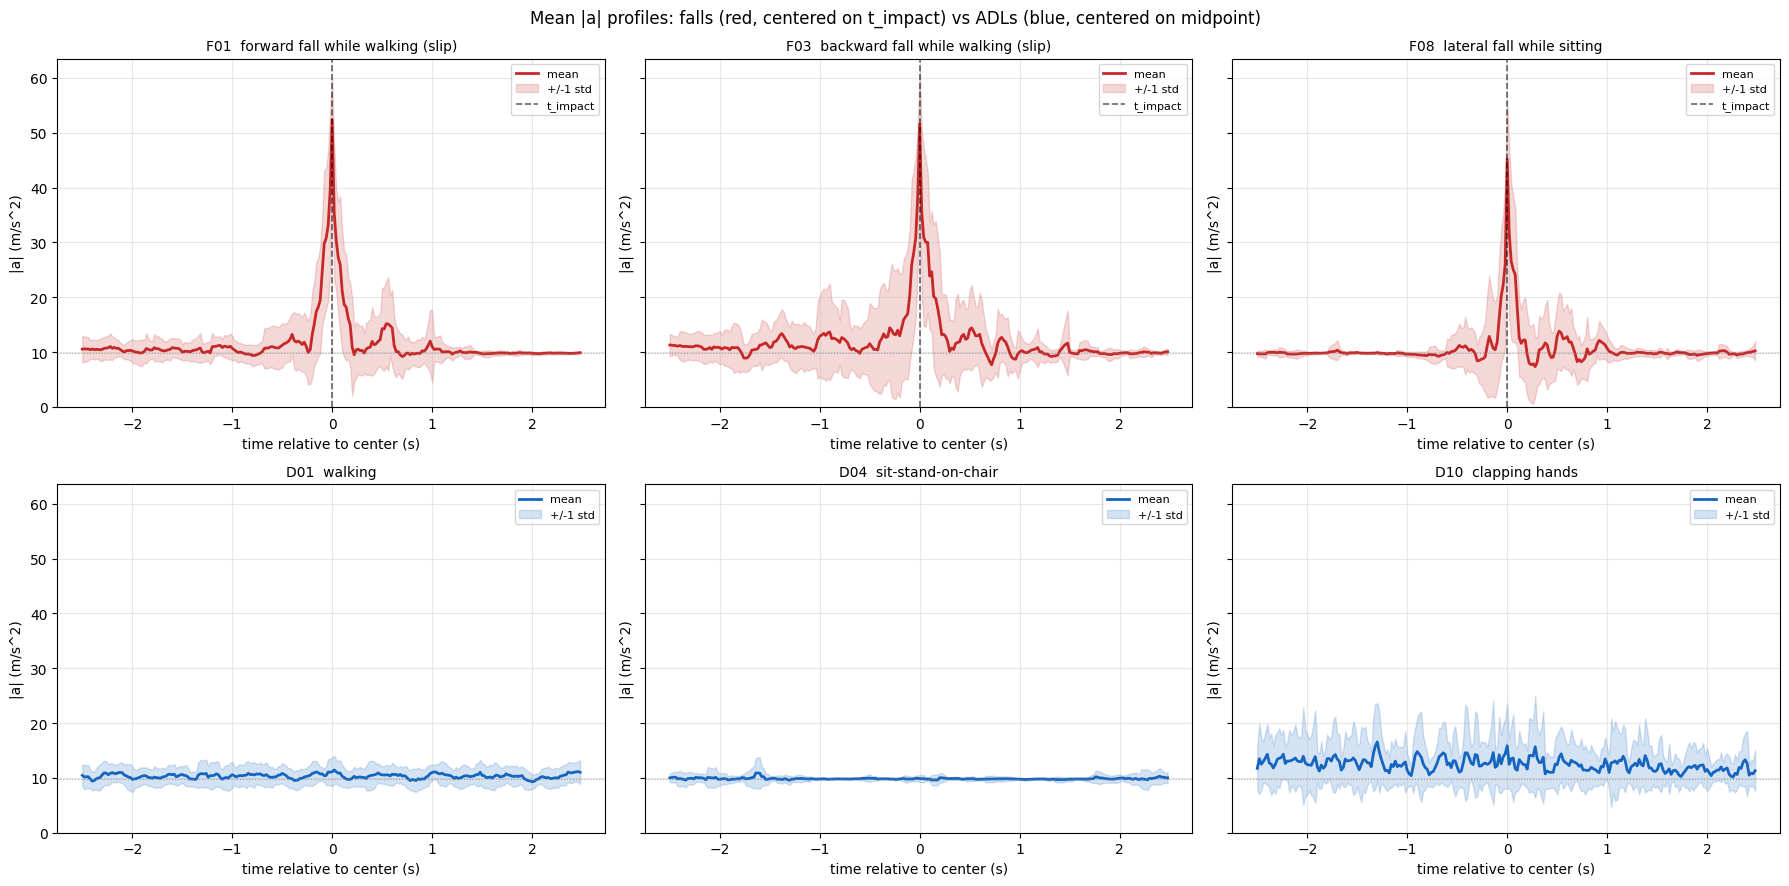

In [6]:
def average_profile(rec_ids, n_max=20, window_seconds=5.0):
    '''Mean +/- std of |a|(t) across the first n_max recordings.

    For falls: align on t_impact (peaks land at t = 0).
    For ADLs:  align on recording midpoint.
    '''
    win_samples = int(window_seconds * TARGET_HZ)
    half = win_samples // 2

    profiles = []
    for rec_id in rec_ids[:n_max]:
        try:
            rec = load_recording(DATA_ROOT, rec_id,
                                 fall_timestamps=fall_ts,
                                 include_orientation=False)
            mag = magnitude(rec.accel)

            if rec_id.is_fall and rec.fall_window:
                ann = find_impact(rec.time, rec.accel, rec.fall_window)
                if not ann.valid:
                    continue
                impact_idx = int(round((ann.t_impact_s - rec.time[0])
                                       * TARGET_HZ))
                center = impact_idx
            else:
                center = len(mag) // 2

            start = center - half
            end = center + (win_samples - half)
            if start < 0 or end > len(mag):
                pad_start = max(0, -start)
                pad_end = max(0, end - len(mag))
                seg = mag[max(0, start):min(len(mag), end)]
                seg = np.pad(seg, (pad_start, pad_end), constant_values=9.81)
            else:
                seg = mag[start:end]

            if len(seg) == win_samples:
                profiles.append(seg)
        except Exception:
            continue

    if not profiles:
        return None, None, None
    arr = np.array(profiles)
    t_axis = (np.arange(win_samples) - half) / TARGET_HZ
    return t_axis, arr.mean(axis=0), arr.std(axis=0)


plot_targets = [
    ("F01  forward fall while walking (slip)",  "F01"),
    ("F03  backward fall while walking (slip)", "F03"),
    ("F08  lateral fall while sitting",         "F08"),
    ("D01  walking",                            "D01"),
    ("D04  sit-stand-on-chair",                 "D04"),
    ("D10  clapping hands",                     "D10"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharey=True)
y_max_seen = 0.0
for ax, (label, code_id) in zip(axes.flat, plot_targets):
    recs = discover_recordings(DATA_ROOT, movements=[code_id])
    t_axis, mean, std = average_profile(recs, n_max=20)
    if t_axis is None:
        ax.set_title(f"{label}  (no usable data)")
        continue
    is_fall = code_id.startswith("F")
    color = "#c62828" if is_fall else "#1565c0"
    ax.plot(t_axis, mean, color=color, lw=2.0, label="mean")
    ax.fill_between(t_axis, mean - std, mean + std,
                    color=color, alpha=0.18, label="+/-1 std")
    ax.axhline(9.81, color="gray", ls=":", lw=0.8, alpha=0.7)
    if is_fall:
        ax.axvline(0, color="black", ls="--", lw=1.2, alpha=0.6,
                   label="t_impact")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("time relative to center (s)")
    ax.set_ylabel("|a| (m/s^2)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="upper right")
    y_max_seen = max(y_max_seen, float(np.max(mean + std)) + 2)

for ax in axes.flat:
    ax.set_ylim(0, max(45.0, y_max_seen))

fig.suptitle(
    "Mean |a| profiles: falls (red, centered on t_impact) vs ADLs (blue, centered on midpoint)",
    fontsize=12,
)
fig.tight_layout()
plt.show()

## What this proves about Week A

1. **The `t_impact` derivation is well-aligned** with the dataset's manual
   labels — lag is consistently positive and mostly inside the
   literature-expected 0.5–1.5 s range.
2. **Peak magnitudes** at the derived `t_impact` sit well above the 20 m/s²
   (~2g) sanity threshold for the vast majority of recordings, so the
   threshold is not pruning real falls.
3. **Falls vs ADLs are visibly separable** at the magnitude level alone —
   falls show a sharp spike around `t_impact` that none of the ADL traces
   reach. The engineered features (jerk, FFT entropy, SMA) should amplify
   this separation further.

The data foundation is sound. **Next:** MLflow scaffolding and the first
edge-model baseline (Week B).